In [2]:
!pip install yfinance scikit-learn matplotlib pandas numpy

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 5.7 MB/s  0:00:00

   ---------------------------------------- 0/4 [peewee]
   ---------------------------------------- 0/4 [peewee]
   ---------- ----------------------------- 1/4 [multitasking]
   -------------------- ------------------- 2/4 [curl_cffi]
   -------------------- ------------------- 2/4 [curl_cffi]
   ------------------------------ --------- 3/4 [yfinance]
   ------------------------------ --------- 3/4 [yfinance]
   ------------------------------ --------- 3/4 [yfinance]
   ---------------------------------------- 4/4 [yfinance]



In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import os


# Fetch historical data for Nifty 50


In [12]:
print("Fetching Nifty 50 data...")
ticker = "^NSEI"  # Yahoo Finance symbol for Nifty 50
data = yf.download(ticker, start="2018-01-01", end="2026-01-01")


[*********************100%***********************]  1 of 1 completed

Fetching Nifty 50 data...


# Clean multi-level column index if present in newer yfinance versions
* Feature Engineering: Calculate Returns and Realized Volatility
* Log returns are preferred in quantitative finance for their additive properties



In [14]:
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

# 21-day rolling standard deviation annualized (approx 252 trading days a year)
window = 21
data['Realized_Vol'] = data['Log_Return'].rolling(window=window).std() * np.sqrt(252)

# Create feature lags (using past volatility to predict future volatility)
data['Vol_Lag1'] = data['Realized_Vol'].shift(1)
data['Vol_Lag2'] = data['Realized_Vol'].shift(2)
data['Vol_Lag5'] = data['Realized_Vol'].shift(5)

# Target: We want to predict TOMORROW's volatility
data['Target_Vol'] = data['Realized_Vol'].shift(-1)

# Drop any NaN rows caused by rolling windows and shifting
data.dropna(inplace=True)

# Define Features (X) and Target (y)


In [15]:
feature_cols = ['Vol_Lag1', 'Vol_Lag2', 'Vol_Lag5', 'Log_Return']
X = data[feature_cols]
y = data['Target_Vol']


# Time-Series Train/Test Split (80% Train, 20% Test)
## Crucial: Do not use train_test_split(shuffle=True) for time-series!


In [16]:
split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


# Initialize and Train Random Forest

In [17]:
print("Training Random Forest Regressor...")
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

Training Random Forest Regressor...


,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
# Evaluate the Model

predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("\n--- Model Performance ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2_score: {r2:.4f}")



--- Model Performance ---
Root Mean Squared Error (RMSE): 0.0159
R2_score: 0.8901


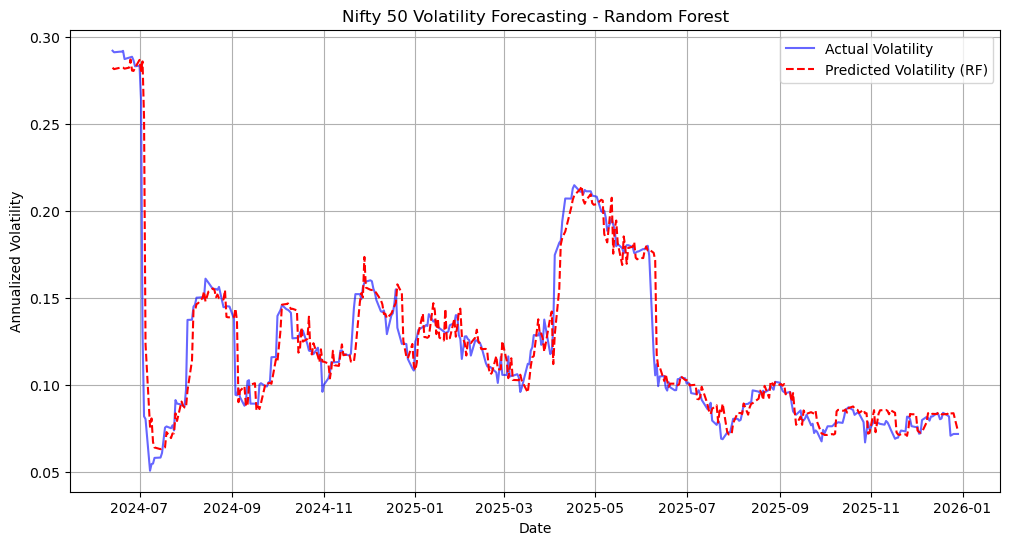

In [23]:
#  Ploting Graph

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label="Actual Volatility", color="blue", alpha=0.6)
plt.plot(y_test.index, predictions, label="Predicted Volatility (RF)", color="red", linestyle="--")
plt.title("Nifty 50 Volatility Forecasting - Random Forest")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.savefig('images/nifty_volatility_forecast.png', bbox_inches='tight', dpi=300)

plt.show()

# Convert annualized predictions back to daily volatility 
##  (Since annualized it earlier by multiplying by sqrt(252))



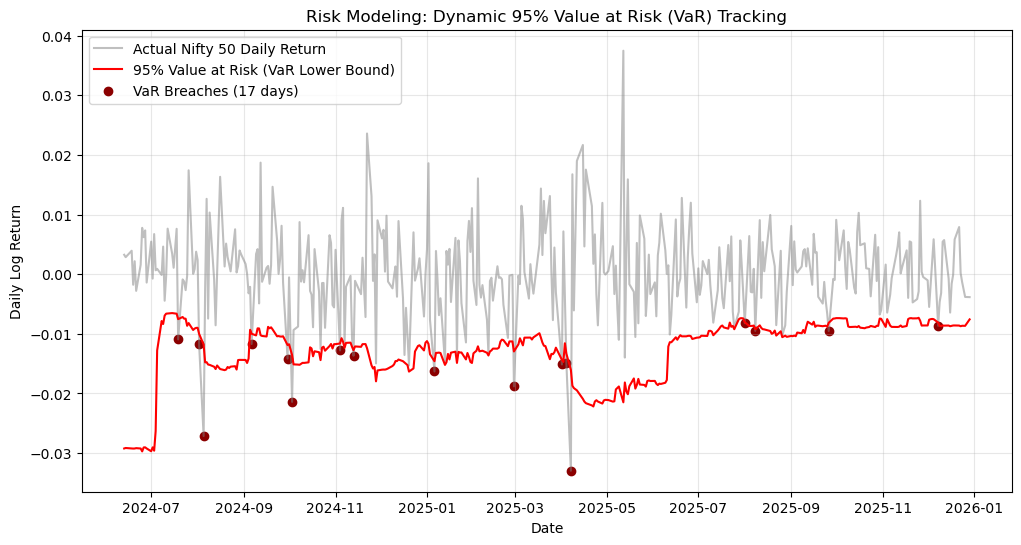

In [24]:
daily_predicted_vol = predictions / np.sqrt(252)

# Calculate Daily Log Returns for the test period to compare against risk threshold
# map y_test index back to the original log returns
test_returns = data.loc[y_test.index, 'Log_Return'].values

# Define Confidence Level (95%)
# Z-score for 95% confidence standard normal distribution is ~1.645
z_score = 1.645
parametric_VaR_95 = - (z_score * daily_predicted_vol)

# dashboard Plot

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, test_returns, label="Actual Nifty 50 Daily Return", color="gray", alpha=0.5)
plt.plot(y_test.index, parametric_VaR_95, label="95% Value at Risk (VaR Lower Bound)", color="red", linestyle="-")

# Highlight breaches (when actual loss was worse than predicted VaR)

breaches = test_returns < parametric_VaR_95
plt.scatter(y_test.index[breaches], test_returns[breaches], color='darkred', marker='o', label=f'VaR Breaches ({sum(breaches)} days)')

plt.title("Risk Modeling: Dynamic 95% Value at Risk (VaR) Tracking")
plt.xlabel("Date")
plt.ylabel("Daily Log Return")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.savefig('images/Risk Modeling.png', bbox_inches='tight', dpi=300)

plt.show()

# Calculate Breach Ratio (Expected to be around 5% if the model is perfectly calibrated)

In [26]:
breach_ratio = (sum(breaches) / len(test_returns)) * 100
print(f"--- Risk Model Validation ---")
print(f"Total Trading Days Evaluated: {len(test_returns)}")
print(f"Number of VaR Violations: {sum(breaches)}")
print(f"Actual Breach Ratio: {breach_ratio:.2f}% (Target: 5.00%)")

--- Risk Model Validation ---
Total Trading Days Evaluated: 384
Number of VaR Violations: 17
Actual Breach Ratio: 4.43% (Target: 5.00%)
